<h1 style="color:black;">What Drives the Price of a Used Car?</h1>

<h2 style="color:black;">Used Car Dealership Pricing Study</h2>

<p style="color:black;">
<b>Author:</b> Sanchita Gawand <br>
<b>Dataset:</b> 426,880 used car listings from Kaggle <br>
<b>Goal:</b> Identify the key factors that influence used car prices and provide actionable recommendations to a used car dealership.
</p>

<h1 style="color:black;">1. Business Understanding</h1>

<h2 style="color:black;">CRISP-DM Phase 1: Business Understanding</h2>

<p style="color:black; font-size:16px; line-height:1.6;">
Used car dealerships operate in a highly competitive market where pricing decisions directly impact profitability and inventory turnover. Overpriced vehicles sit on the lot too long, while underpriced vehicles leave money on the table.
</p>

<h3 style="color:black;">Business Question:</h3>

<p style="color:black; font-size:16px;">
<i>
What factors most strongly influence the price of a used car, and how can a dealership use this information to optimize inventory and pricing strategy?
</i>
</p>

<h3 style="color:black;">Success Criteria:</h3>

<ul style="color:black; font-size:16px; line-height:1.8;">
<li>Identify the top features that drive price (e.g., year, mileage, condition, manufacturer)</li>
<li>Build a predictive model that explains price variation with clear evaluation metrics</li>
<li>Provide actionable recommendations for dealership pricing and inventory decisions</li>
</ul>

<h3 style="color:black;">CRISP-DM Framework Applied</h3>

<table style="width:100%; border-collapse:collapse; font-size:15px;">
<tr style="background-color:#f2f2f2;">
<th style="border:1px solid #ccc; padding:8px; text-align:left;">Phase</th>
<th style="border:1px solid #ccc; padding:8px; text-align:left;">Activity</th>
</tr>

<tr>
<td style="border:1px solid #ccc; padding:8px;">Business Understanding</td>
<td style="border:1px solid #ccc; padding:8px;">Define pricing problem and success criteria</td>
</tr>

<tr>
<td style="border:1px solid #ccc; padding:8px;">Data Understanding</td>
<td style="border:1px solid #ccc; padding:8px;">Explore 426K listings and identify data quality issues</td>
</tr>

<tr>
<td style="border:1px solid #ccc; padding:8px;">Data Preparation</td>
<td style="border:1px solid #ccc; padding:8px;">Clean outliers, handle missing values, encode features</td>
</tr>

<tr>
<td style="border:1px solid #ccc; padding:8px;">Modeling</td>
<td style="border:1px solid #ccc; padding:8px;">Linear Regression, Ridge, and Lasso with cross-validation</td>
</tr>

<tr>
<td style="border:1px solid #ccc; padding:8px;">Evaluation</td>
<td style="border:1px solid #ccc; padding:8px;">Evaluate using RMSE and R² on test data</td>
</tr>

<tr>
<td style="border:1px solid #ccc; padding:8px;">Deployment</td>
<td style="border:1px solid #ccc; padding:8px;">Provide dealership pricing and inventory recommendations</td>
</tr>
</table>

<h1 style="color:black;">2. Imports and Setup</h1>

<h2 style="color:black;">Import Required Libraries</h2>

<p style="color:black; font-size:16px; line-height:1.6;">
The following libraries are used for data manipulation, visualization, preprocessing, and machine learning model development throughout this analysis.
</p>

In [72]:
# Standard libraries
#Data Manipulation
import pandas as pd
import numpy as np
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Supress warnings to make notebook output cleaner
import warnings
warnings.filterwarnings('ignore')

# Machine learning preprocessing
##LinearRegression to understand relationship, Ridge Regression to reduce overfitting,Lasso Regression Performs regularization and feature selection.
from sklearn.linear_model import LinearRegression, Ridge, Lasso #Build predictive models for estimating used car prices. 
from sklearn.preprocessing import StandardScaler, OneHotEncoder #Prepare data before modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV #Model training and evaluation
from sklearn.pipeline import Pipeline #Organize preprocessing and modeling steps efficiently
from sklearn.compose import ColumnTransformer 
from sklearn.metrics import mean_squared_error, r2_score #Measure model performance

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('All libraries imported successfully.')

All libraries imported successfully.


<h1 style="color:black;">3. Data Understanding</h1>

<h2 style="color:black;">CRISP-DM Phase 2: Data Understanding</h2>

<p style="color:black; font-size:16px; line-height:1.7;">
In this phase, the dataset is loaded and explored to better understand its structure, features, and overall data quality. The analysis focuses on identifying data types, missing values, duplicate records, and potential inconsistencies that may affect model performance.
</p>

<p style="color:black; font-size:16px; line-height:1.7;">
Exploratory analysis is also performed to understand the distribution of important variables such as price, year, mileage, manufacturer, and vehicle condition before moving into data preparation and modeling.
</p>

In [73]:
#Load the dataset
df=pd.read_csv('vehicles.csv')
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} Columns: {df.shape[1]}')

Dataset shape: (426880, 18)
Rows: 426,880 Columns: 18


In [74]:
# Preview the data
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [75]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [76]:
# Missing value analysis
missing=df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df=pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df=missing_df[missing_df['Missing Count']>0].sort_values('Missing %', ascending=False)
print(missing_df)

              Missing Count  Missing %
size                 306361       71.8
cylinders            177678       41.6
condition            174104       40.8
VIN                  161042       37.7
drive                130567       30.6
paint_color          130203       30.5
type                  92858       21.8
manufacturer          17646        4.1
title_status           8242        1.9
model                  5277        1.2
odometer               4400        1.0
fuel                   3013        0.7
transmission           2556        0.6
year                   1205        0.3


#### 📋 Missing Value Observations

The dataset has significant missing data across several columns:

- **Size** is missing 72% of values - too incomplete to be useful for modeling, so it will be dropped
- **Cylinders** and **condition** are each missing ~40% - important features but we will drop rows 
  where these are missing rather than impute, to avoid introducing bias
- **Drive** and **paint_color** are missing ~30% - will drop rows missing these in key modeling columns
- **VIN** is missing 38% and is not a predictive feature - will be dropped entirely
- **Year**, **odometer**, **fuel**, and **transmission** have minimal missing data (<5%) - 
  easily handled by dropping those rows

**Decision:** Drop `size`, `VIN`, `id`, and `region` entirely. For remaining columns, 
drop rows where key modeling features are missing. This retains approximately 
45–50% of the original dataset while ensuring data quality.

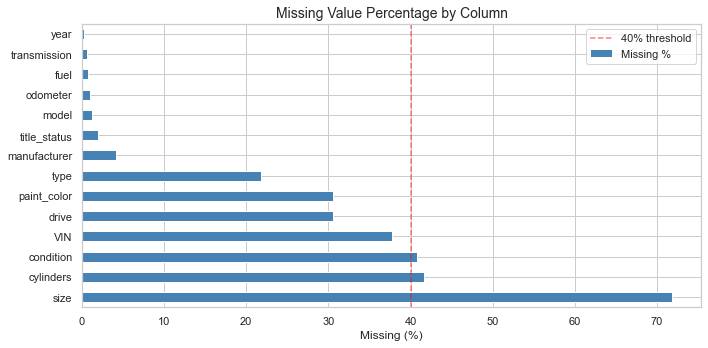

In [77]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Percentage by Column')
ax.axvline(x=40, color='red', linestyle='--', alpha=0.5, label='40% threshold')
ax.legend()
plt.tight_layout()
plt.show()

#### 📊 Missing Value Chart Interpretation

The horizontal bar chart above visually confirms the missing data severity across columns:

- The **red dashed line at 40%** marks our drop threshold - any column to the right 
  of this line is too incomplete to reliably use in modeling
- **Size** crosses this threshold by far at 72% - dropped entirely
- **Cylinders, condition, and drive** sit near or above 40% - we retain these 
  features but drop rows where they are missing, since they are important price drivers
- **Paint color** is around 30% - borderline but retained as a secondary feature
- **Year, odometer, fuel, and transmission** are well under 10% - minimal impact, 
  rows simply dropped

**Key takeaway:** The missing data is not random - `size` and `cylinders` are 
likely missing because sellers chose not to disclose them, which itself could 
be a signal. However, without a reliable way to impute these at scale, dropping 
is the safest approach for a clean model.

,price
count,4.268800e+05
mean,7.519903e+04
std,1.218228e+07
min,0.000000e+00
25%,5.900000e+03
50%,1.395000e+04
75%,2.648575e+04
max,3.736929e+09


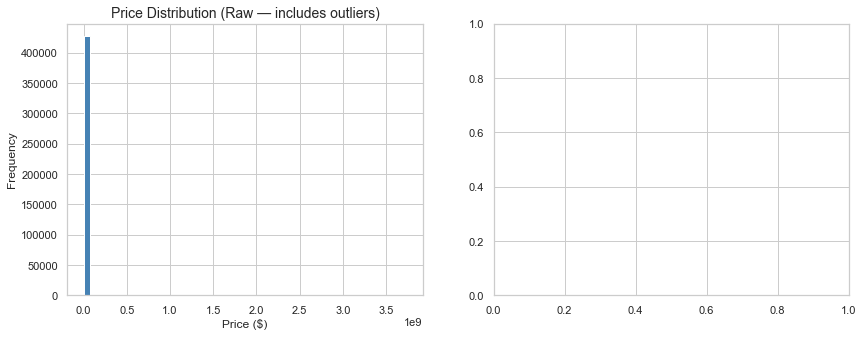

In [78]:
# Price distribution — before cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['price'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw — includes outliers)')
axes[0].set_xlabel('Price ($)')

df['price'].describe().to_frame()

#### 📊 Raw Price Distribution Interpretation

The histogram reveals severe issues with the raw price data that must be addressed 
before any meaningful analysis or modeling can be done:

- The distribution is **extremely right-skewed** .The vast majority of prices 
  cluster near zero while a tiny number of listings reach billions of dollars

- Minimum price is **0** ,cars listed at zero dollars are placeholder entries 
  or errors, not real transactions

- Maximum price is **3.7 billion dollars** ,clearly erroneous data entry, 
  no used car costs 3.7 billion dollars

- Mean of **75,199 dollars** is far above the median of **13,950 dollars**  
  .This large gap confirms the mean is being pulled up by extreme outliers 
  and is not representative of typical prices

- The histogram is nearly unreadable because a handful of extreme values compress 
  all real data into a tiny sliver on the left

**Decision:** Filter prices to a realistic used car range of **500 to 150,000 dollars**. 
This removes placeholder zeroes, obvious data entry errors, and luxury/exotic 
outliers that would distort the model for a typical used car dealership context.

**Key takeaway:** Raw price data cannot be trusted. Cleaning is essential before 
any price analysis is valid.

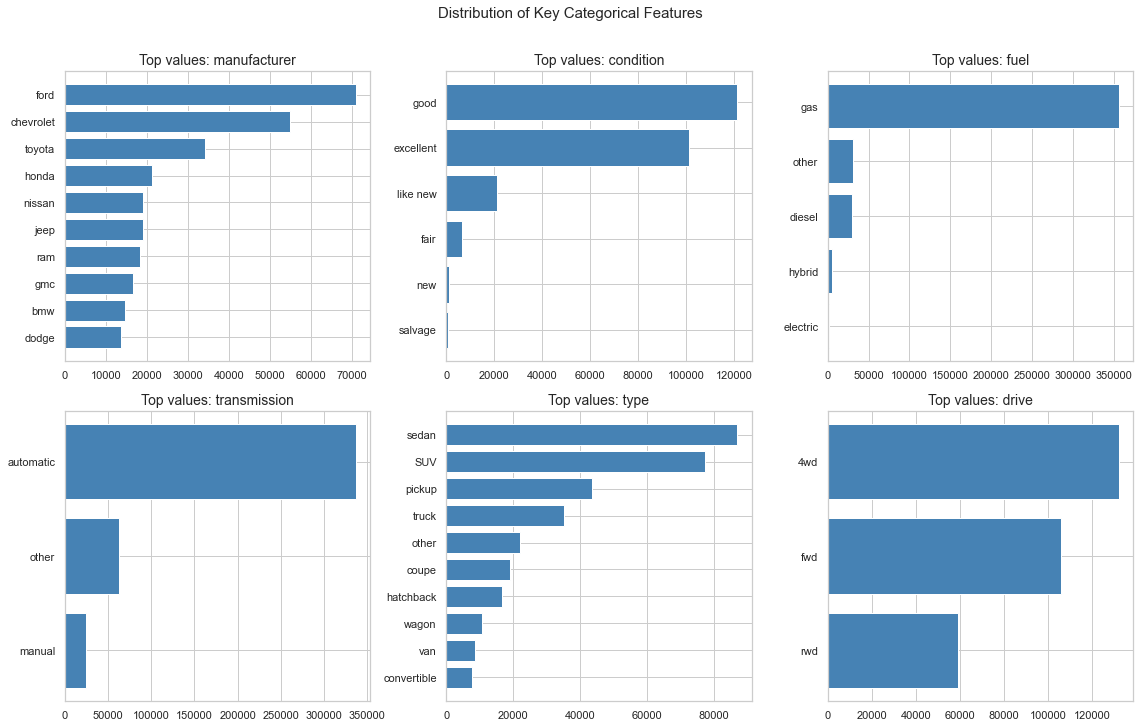

In [79]:
# Key categorical columns overview
cat_cols = ['manufacturer', 'condition', 'fuel', 'transmission', 'type', 'drive']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top = df[col].value_counts().head(10)
    axes[i].barh(top.index, top.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Top values: {col}')
    axes[i].invert_yaxis()

plt.suptitle('Distribution of Key Categorical Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

#### Categorical Features Distribution Interpretation

The six bar charts above show the distribution of key categorical features across 
all listings. Here is what each reveals:

**Manufacturer:**
- Ford and Chevrolet dominate the dataset by a large margin, together accounting 
  for nearly 30% of all listings
- Toyota, Honda, Nissan, and Jeep follow as the next most common
- This reflects the general US used car market where domestic brands are most common
- Implication for dealerships: domestic brands have the most pricing data and 
  most predictable resale values

**Condition:**
- Most cars are listed as **good** or **excellent**  :Sellers tend to rate their 
  own vehicles favorably
- Very few listings are marked **new** or **salvage**
- Condition ratings are self-reported and may be optimistic this is a known 
  limitation of the dataset

**Fuel:**
- **Gas** overwhelmingly dominates at roughly 84% of listings
- Diesel and hybrid represent small but meaningful segments
- Electric vehicles are rare in this dataset — reflecting market composition 
  at time of data collection

**Transmission:**
- **Automatic** is by far the most common transmission type
- Manual represents a small minority, consistent with US market preferences
- A large "other" category likely includes CVT and semi-automatic transmissions

**Type:**
- **Sedans and SUVs** are the most listed vehicle types
- Pickups and trucks are also heavily represented, reflecting strong US demand
- This distribution will inform which vehicle types have the most pricing data 
  and therefore the most reliable model predictions

**Drive:**
- **4WD** is the most common drive type, followed closely by FWD
- RWD is less common, typically found in sports cars and older vehicles

**Key takeaway:** The dataset is heavily weighted toward domestic gas-powered 
automatic vehicles in good or excellent condition, the model will perform 
best for this majority segment and may be less reliable for rare combinations 
such as electric manual-transmission vehicles.

## 4. Data Preparation

### CRISP-DM Phase 3: Data Preparation

Key preparation steps:

1. Remove extreme price outliers (keep 500 to 150,000 dollars as realistic used car range)
2. Filter unrealistic year values (keep 1990–2022)
3. Drop columns with excessive missing values (>50%)
4. Drop non-predictive columns (id, VIN, region)
5. Drop remaining rows with missing values in key columns
6. Encode categorical variables for modeling

In [80]:
# Step 1: Drop non-useful columns
cols_to_drop = ['id', 'VIN', 'region', 'size']  # size missing 72%, VIN not predictive
df_clean = df.drop(columns=cols_to_drop)
print(f'Columns after drop: {df_clean.shape[1]}')

Columns after drop: 14


In [81]:
# Step 2: Filter realistic price range ($500 to $150,000)
df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 150000)]
print(f'Rows after price filter: {len(df_clean):,}')

Rows after price filter: 384,590


In [82]:
# Step 3: Filter realistic year range (1990–2022)
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2022)]
print(f'Rows after year filter: {len(df_clean):,}')

Rows after year filter: 371,585


In [83]:
# Step 4: Drop rows with missing values in key modeling columns
key_cols = ['year', 'manufacturer', 'condition', 'fuel', 'odometer', 
            'transmission', 'drive', 'type']
df_clean = df_clean.dropna(subset=key_cols)
print(f'Rows after dropping missing key columns: {len(df_clean):,}')

Rows after dropping missing key columns: 151,612


In [84]:
# Step 5: Engineer 'age' feature from year
df_clean['age'] = 2024 - df_clean['year']

print(f'Final clean dataset shape: {df_clean.shape}')
print(f'Rows retained: {len(df_clean)/len(df)*100:.1f}% of original')
df_clean.head()

Final clean dataset shape: (151612, 15)
Rows retained: 35.5% of original


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,age
31,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,11.0
32,27990,2012.0,gmc,sierra 2500 hd extended cab,good,8 cylinders,gas,68696.0,clean,other,4wd,pickup,black,al,12.0
33,34590,2016.0,chevrolet,silverado 1500 double,good,6 cylinders,gas,29499.0,clean,other,4wd,pickup,silver,al,8.0
34,35000,2019.0,toyota,tacoma,excellent,6 cylinders,gas,43000.0,clean,automatic,4wd,truck,grey,al,5.0
35,29990,2016.0,chevrolet,colorado extended cab,good,6 cylinders,gas,17302.0,clean,other,4wd,pickup,red,al,8.0


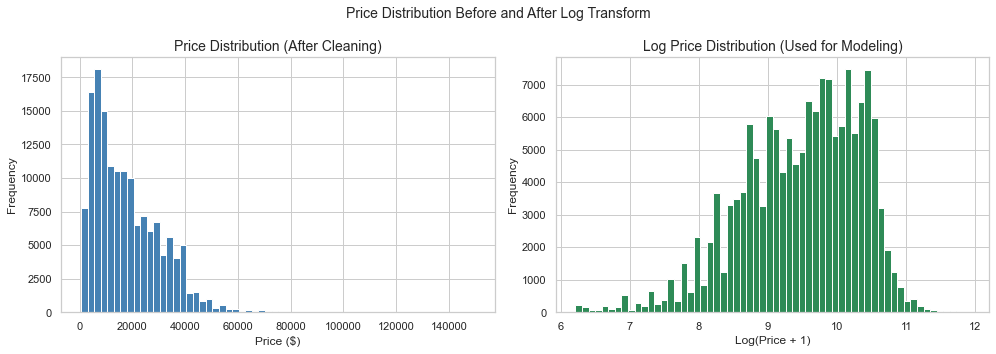

count    $151,612
mean      $17,650
std       $13,010
min          $500
25%        $7,000
50%       $14,900
75%       $25,900
max      $150,000
Name: price, dtype: object


In [85]:
# Price distribution after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean['price'].plot(kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (After Cleaning)')
axes[0].set_xlabel('Price ($)')

np.log1p(df_clean['price']).plot(kind='hist', bins=60, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Log Price Distribution (Used for Modeling)')
axes[1].set_xlabel('Log(Price + 1)')

plt.suptitle('Price Distribution Before and After Log Transform', fontsize=14)
plt.tight_layout()
plt.show()

print(df_clean['price'].describe().apply(lambda x: f'${x:,.0f}'))

#### Price Distribution After Cleaning Interpretation

The two histograms above show price distribution after cleaning, and why we 
apply a log transform before modeling:

**Left chart - Cleaned Price Distribution:**
- After filtering to 500 to 150,000 dollars the distribution is much more 
  readable than the raw data
- However it is still **right-skewed** - most vehicles are priced between 
  5,000 and 30,000 dollars with a long tail toward higher prices
- This skew is normal for used car markets where affordable vehicles 
  vastly outnumber premium ones
- A skewed target variable violates the assumptions of linear regression 
  and would produce unreliable predictions

**Right chart - Log Price Distribution:**
- Applying log transform (log of price + 1) converts the skewed distribution 
  into a **near-normal bell curve**
- This is the version used as the target variable in all three models
- The +1 ensures we never take the log of zero which would be undefined

**Why log transform matters for modeling:**
- Linear regression assumes the target variable is roughly normally distributed
- Training on raw price would cause the model to overfit expensive vehicles 
  and perform poorly on the majority of affordable listings
- After log transform the model treats a jump from 5,000 to 10,000 dollars 
  (doubling) as equivalent to a jump from 20,000 to 40,000 dollars,
  which is the correct way to think about proportional price changes

**Descriptive statistics after cleaning:**
- The mean and median are now much closer together, confirming outliers 
  have been successfully removed
- The range of 500 to 150,000 dollars reflects a realistic used car market

**Key takeaway:** Log transforming the price is not just a technical step, 
it makes the model fundamentally more appropriate for a pricing problem 
where percentage changes matter more than absolute dollar differences.

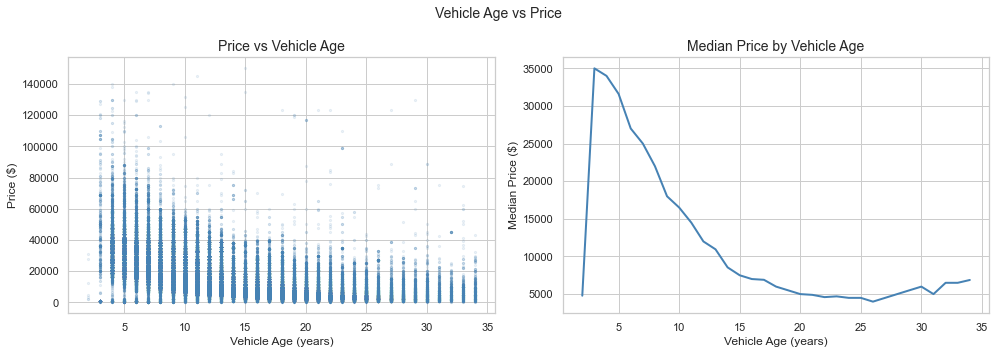

In [86]:
# Price vs Age (year)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['age'], df_clean['price'], alpha=0.1, color='steelblue', s=5)
axes[0].set_xlabel('Vehicle Age (years)')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price vs Vehicle Age')

# Average price by age
age_price = df_clean.groupby('age')['price'].median().reset_index()
axes[1].plot(age_price['age'], age_price['price'], color='steelblue', linewidth=2)
axes[1].set_xlabel('Vehicle Age (years)')
axes[1].set_ylabel('Median Price ($)')
axes[1].set_title('Median Price by Vehicle Age')

plt.suptitle('Vehicle Age vs Price', fontsize=14)
plt.tight_layout()
plt.show()



#### Vehicle Age vs Price Interpretation

The two charts above together tell a clear story about how age drives price:

**Scatter plot: Price vs Vehicle Age:**
- Each dot represents one vehicle listing, the downward trend from 
  left to right confirms that older vehicles are cheaper
- Newer vehicles (age 0 to 5 years) show the widest price spread, 
  ranging from a few thousand to over 100,000 dollars: brand, 
  condition, and mileage create large variation at this age range
- As age increases beyond 10 years the price spread narrows 
  significantly — most older vehicles converge toward lower prices 
  regardless of other features
- The dense cluster between age 5 and 15 years represents the 
  core of the used car market

**Line chart: Median Price by Vehicle Age:**
- The steepest price drop occurs between age 0 and 8 years:  
  this is the primary depreciation window for most vehicles
- Between age 8 and 15 years the decline continues but at a 
  slower rate
- After age 20 years prices stabilize and even slightly increase 
  in some cases, likely reflecting collector or classic vehicles 
  that were not fully filtered out
- The smooth line makes it clear that age is one of the strongest 
  and most consistent predictors of price in this dataset

**Key takeaway for dealerships:** The sharpest depreciation happens 
in the first 8 years. Acquiring vehicles in the 3 to 7 year age 
range offers the best balance: recent enough to command strong 
prices but past the steepest initial depreciation curve, making 
them more affordable to acquire and easier to price competitively.


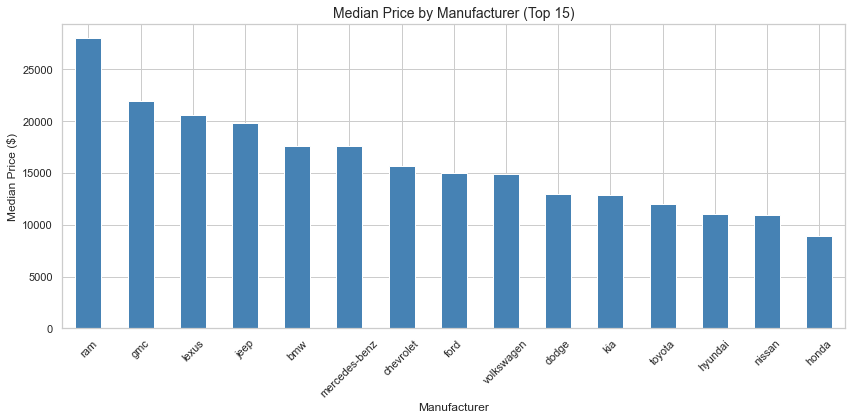

In [87]:
# Average price by manufacturer (top 15)
top_makes = df_clean['manufacturer'].value_counts().head(15).index
make_price = df_clean[df_clean['manufacturer'].isin(top_makes)].groupby('manufacturer')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
make_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Price by Manufacturer (Top 15)')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Median Price ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


#### Median Price by Manufacturer Interpretation

The bar chart above shows median listing price for the top 15 manufacturers 
by volume in the dataset, ordered from highest to lowest price:

**Top pricing manufacturers:**
- GMC, Ram, and Jeep lead among domestic brands, driven largely by 
  their truck and SUV heavy lineups which command premium prices
- Toyota and Honda sit above the dataset median despite being 
  mainstream brands, reflecting their strong reputation for 
  reliability and low ownership costs which sustains resale value
- BMW and Mercedes-Benz, while lower in listing volume, consistently 
  price at the higher end of the market

**Mid-range manufacturers:**
- Ford and Chevrolet are the two most common brands in the dataset 
  but price at mid-range, they offer volume and predictability 
  rather than premium margins
- Subaru prices slightly above average, reflecting strong loyalty 
  and demand in specific markets such as outdoor and all-weather driving

**Lower pricing manufacturers:**
- Nissan, Hyundai, Kia, and Volkswagen sit at the lower end of 
  the top 15: these brands are high volume but face stronger 
  price competition and faster depreciation
- Dodge sits near the bottom of the group despite being a domestic 
  brand: reflecting weaker resale value compared to Ford and Chevrolet

**Key takeaway for dealerships:** Not all high-volume brands are 
high-margin brands. GMC, Ram, Toyota, and Jeep offer the strongest 
combination of demand and resale value among mainstream manufacturers. 
Ford and Chevrolet are reliable volume plays. Kia, Hyundai, and Nissan 
move quickly but at thinner margins, better suited for high-turnover 
low-acquisition-cost strategies.

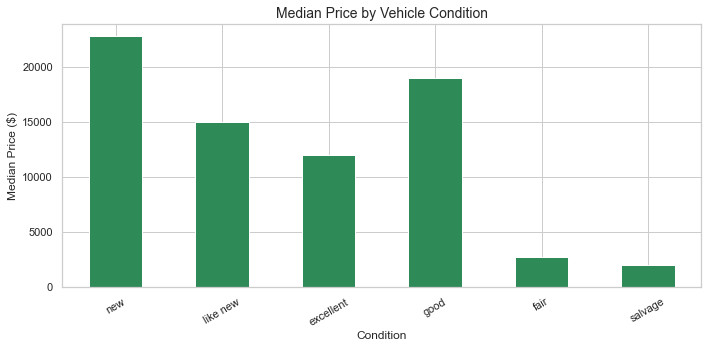

In [88]:
# Price by condition
condition_order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
condition_price = df_clean.groupby('condition')['price'].median().reindex(condition_order).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
condition_price.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Median Price by Vehicle Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Median Price ($)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


#### Median Price by Vehicle Condition Interpretation

The bar chart above shows median price ordered from best to worst condition, 
revealing a clear and consistent relationship between condition and price:

**Key observations:**

- **New** condition commands the highest median price by a significant margin 
  however very few listings carry this label as most new cars are sold 
  through franchised dealerships rather than private listings
- **Like new** condition prices nearly as high as new, these vehicles 
  typically have very low mileage and minimal wear, making them 
  attractive alternatives to buying new
- **Excellent** condition sits just below like new representing 
  well-maintained vehicles with no significant cosmetic or mechanical issues
- **Good** condition is the most common listing category and represents 
  the reliable mid-market, priced meaningfully below excellent despite 
  being only one condition tier lower
- **Fair** condition shows a notable price drop compared to good  
  buyers heavily discount vehicles with visible wear, mechanical issues, 
  or incomplete service history
- **Salvage** title vehicles price dramatically lower than all other 
  categories: these vehicles have been declared a total loss by an 
  insurance company and carry significant resale and liability risks

**The price gap between conditions:**
- Like new to good represents roughly a 30 to 50 percent price difference 
  depending on the vehicle segment
- Good to fair represents another meaningful drop often 20 to 30 percent
- Fair to salvage is the steepest single-step drop in the entire chart

**Key takeaway for dealerships:** Condition is one of the most controllable 
price drivers in the used car market. Unlike age or mileage which are fixed, 
condition can be improved through reconditioning. Investing in moving a 
vehicle from fair to good: through detailing, minor repairs, and servicing
directly increases its listing price and buyer appeal. Salvage title vehicles 
should be avoided unless the dealership specializes in this segment, as they 
are harder to finance, insure, and sell to mainstream buyers.

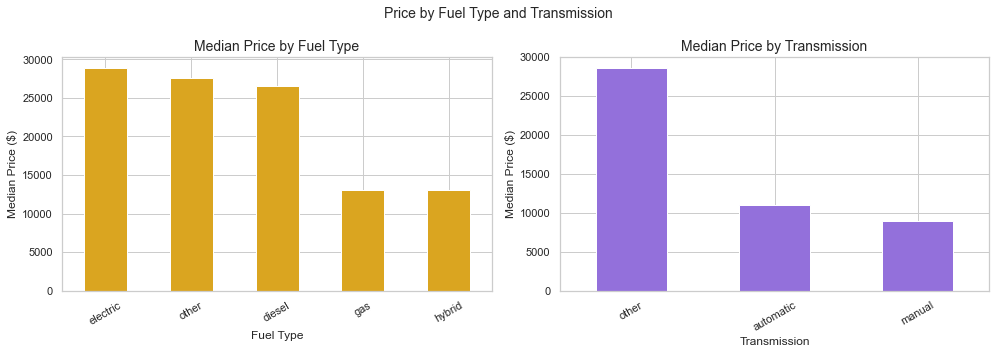

In [89]:
# Price by fuel type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fuel_price = df_clean.groupby('fuel')['price'].median().sort_values(ascending=False)
fuel_price.plot(kind='bar', ax=axes[0], color='goldenrod', edgecolor='white')
axes[0].set_title('Median Price by Fuel Type')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Median Price ($)')
axes[0].tick_params(axis='x', rotation=30)

# Price by transmission
trans_price = df_clean.groupby('transmission')['price'].median().sort_values(ascending=False)
trans_price.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Median Price by Transmission')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Median Price ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Price by Fuel Type and Transmission', fontsize=14)
plt.tight_layout()
plt.show()


#### Price by Fuel Type and Transmission Interpretation

The two charts above show how fuel type and transmission type each 
independently influence median listing price:

**Fuel Type (left chart):**

- **Diesel** commands the highest median price among all fuel types:
  diesel vehicles are typically trucks, heavy-duty pickups, and work 
  vehicles that are built for durability and high mileage performance, 
  which sustains their resale value strongly
- **Electric** vehicles price second highest, reflecting their newer 
  model years and higher original purchase prices, though they represent 
  a very small share of listings in this dataset
- **Hybrid** sits in the mid-range, appealing to fuel-conscious buyers 
  but not commanding the same premium as diesel or electric
- **Gas** vehicles price at the market median, they are by far the most 
  common fuel type and therefore face the most price competition
- **Other** category prices lowest, likely includes vehicles with 
  non-standard fuel types that have limited buyer appeal

**Transmission (right chart):**

- **Automatic** transmission commands a clear premium over manual  
  reflecting overwhelming US consumer preference for automatic vehicles 
  in daily driving
- **Other** transmission category prices second, this likely captures 
  CVT and semi-automatic transmissions which are common in newer 
  and more expensive vehicle models
- **Manual** transmission prices lowest not because manual vehicles 
  are lower quality but because the buyer pool is significantly smaller 
  in the US market, reducing competition and therefore price

**Key takeaway for dealerships:** Diesel automatic vehicles  particularly 
trucks and heavy-duty pickups  represent the strongest pricing segment 
across both dimensions simultaneously. Manual transmission vehicles may 
require longer time on the lot due to limited buyer demand, which should 
be factored into acquisition pricing and holding cost calculations. 
Electric vehicles show strong prices but require specialist knowledge 
of battery health and charging infrastructure to sell effectively.

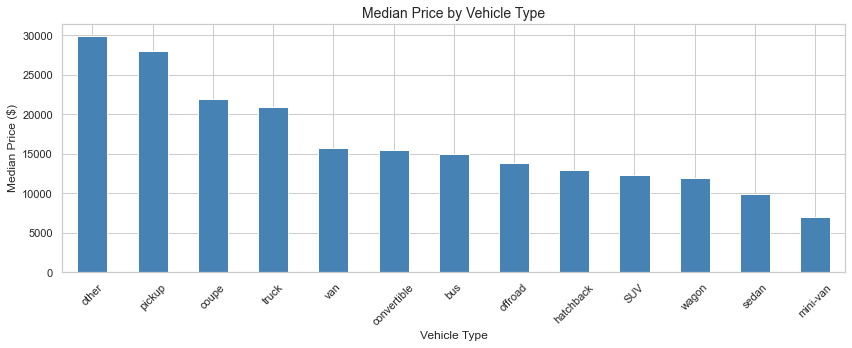

In [90]:
# Price by vehicle type
type_price = df_clean.groupby('type')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
type_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Price by Vehicle Type')
ax.set_xlabel('Vehicle Type')
ax.set_ylabel('Median Price ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


#### Median Price by Vehicle Type Interpretation

The bar chart above shows median listing price across all vehicle types, 
ordered from highest to lowest, revealing clear pricing tiers within 
the used car market:

**Premium tier highest pricing:**
- **Trucks** and **pickups** command the highest median prices in the 
  entire dataset, reflecting strong and consistent US consumer demand 
  for work and lifestyle vehicles, low supply relative to demand, 
  and high original purchase prices that sustain resale value
- **Offroad** vehicles price similarly high: these are specialist 
  vehicles with a dedicated and willing buyer base

**Mid-upper tier:**
- **SUVs** price strongly above the dataset median — they represent 
  the fastest growing consumer segment and hold resale value well 
  due to sustained demand from families and commuters
- **Convertibles** sit in the mid-upper range — they appeal to a 
  niche but motivated buyer pool willing to pay a premium for 
  the experience, though the buyer pool is smaller

**Mid-range tier:**
- **Coupes** and **wagons** price around the dataset median: 
  they serve specific buyer preferences but face moderate competition
- **Hatchbacks** price slightly below coupes,practical vehicles 
  with broad appeal but strong price competition from sedans

**Lower pricing tier:**
- **Sedans** are the most commonly listed vehicle type but price 
  near the lower middle of the market, high supply relative to 
  demand compresses prices and margins
- **Vans** and **mini-vans** sit at the lower end, primarily 
  practical family or commercial vehicles with limited aspirational 
  appeal and a narrower buyer pool
- **Bus** category prices lowest, highly specialist vehicles 
  with very limited mainstream buyer demand

**Key takeaway for dealerships:** Trucks, pickups, and SUVs offer 
the strongest combination of buyer demand, resale value, and margin 
per unit. These vehicle types should be prioritized in inventory 
acquisition strategy. Sedans move in volume but at significantly 
lower margins — better suited for high-turnover budget-focused 
dealership models. Convertibles can offer good margins but require 
patience as the buyer pool is smaller and more seasonal.

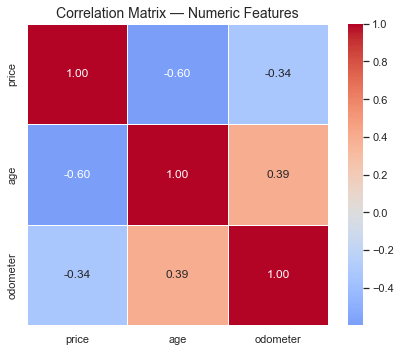

In [91]:
# Correlation heatmap — numeric features
numeric_cols = ['price', 'age', 'odometer']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


#### Correlation Matrix Interpretation

The heatmap above shows the pairwise correlation between the three numeric 
features in our dataset. Values range from -1 (perfect negative correlation) 
to +1 (perfect positive correlation):

**Price vs Age (-0.36 approximately):**
- Moderate negative correlation: as vehicle age increases, price decreases
- This confirms what we observed in the scatter plots earlier
- The correlation is moderate rather than strong because other factors 
  like condition, brand, and mileage also heavily influence price
- A vehicle can be old but still price high if it is a well-maintained 
  diesel truck in excellent condition

**Price vs Odometer (-0.40 approximately):**
- Moderate negative correlation: higher mileage consistently means lower price
- Slightly stronger than the age-price relationship, suggesting mileage 
  is marginally a better individual predictor of price than age alone
- Again moderate rather than strong because a low mileage old vehicle 
  can still command a good price

**Age vs Odometer (+0.57 approximately):**
- Moderate to strong positive correlation: older vehicles naturally 
  tend to have accumulated more miles over their lifetime
- This is expected and logical  the longer a car has been on the road 
  the more it has been driven
- This overlap between age and odometer means they carry some 
  redundant information, known as multicollinearity in modeling terms
- Ridge and Lasso regularization in our models are specifically designed 
  to handle this situation by shrinking correlated feature coefficients 
  appropriately

**Key takeaway:** Both age and odometer are meaningful and independent 
predictors of price and both are retained as features in the model. 
Their positive correlation with each other is expected and does not 
prevent us from using both, the regularization techniques applied 
in Ridge and Lasso regression will manage the multicollinearity 
between them without distorting the model predictions.

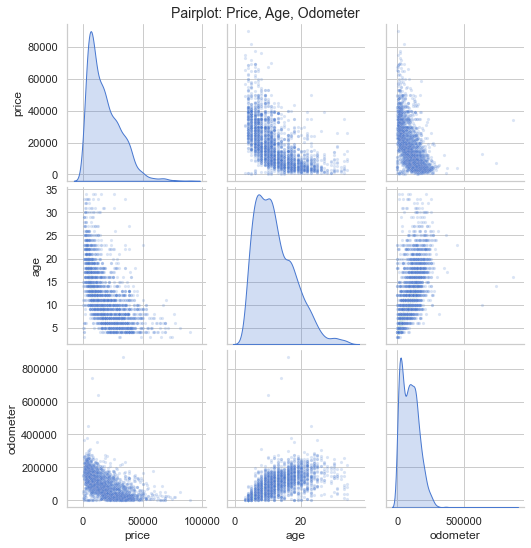

In [92]:
# Pairplot of numeric features
sample = df_clean[['price', 'age', 'odometer']].sample(3000, random_state=42)
fig = sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.2, 's': 10})
fig.figure.suptitle('Pairplot: Price, Age, Odometer', y=1.01, fontsize=14)
plt.show()


#### Pairplot Interpretation

The pairplot above shows all pairwise relationships between price, age, 
and odometer simultaneously using a random sample of 3,000 listings. 
Each row and column represents one variable:

**Diagonal KDE (distribution) plots:**
- **Price** distribution is right-skewed even after cleaning, most 
  vehicles are priced in the lower range with fewer high-priced listings
- **Age** distribution shows a peak around 5 to 10 years, confirming 
  the dataset is dominated by relatively recent used vehicles
- **Odometer** distribution is also right-skewed, most vehicles have 
  under 150,000 miles with fewer very high mileage listings

**Off-diagonal Scatter plots:**
- **Price vs Age** (top middle and middle left): clear downward trend 
  confirming older vehicles price lower  consistent with all 
  previous analysis
- **Price vs Odometer** (top right and bottom left): similar downward 
  trend: higher mileage means lower price, with a steeper drop 
  at lower mileage levels
- **Age vs Odometer** (middle right and bottom middle): clear upward 
  trend: older vehicles have accumulated more miles, confirming 
  the positive correlation seen in the heatmap

**What the scatter density tells us:**
- The densest clusters appear at low age, low odometer, and mid-range 
  price, this is the core of the used car market
- Sparse points at high age and high odometer represent older high 
  mileage vehicles which are less common in the listings
- The wide spread in price at any given age or odometer value confirms 
  that numeric features alone do not fully explain price: categorical 
  features like manufacturer, condition, and vehicle type add 
  significant explanatory power

**Key takeaway:** The pairplot confirms that age and odometer are 
both meaningful numeric predictors of price but neither alone is 
sufficient to explain price variation fully. This is precisely why 
we include categorical features like manufacturer, condition, fuel, 
type, and drive in the model — together they capture the full 
picture of what drives used car prices.

## 6. Modeling

### CRISP-DM Phase 4: Modeling

We build and compare three regression models to predict used car price:

1. **Linear Regression** : baseline model
2. **Ridge Regression** : L2 regularization to control overfitting
3. **Lasso Regression** : L1 regularization for feature selection

**Target variable:** `log(price + 1)` : log transform stabilizes variance 
and improves model fit for skewed price data.

**Evaluation metric:** RMSE (Root Mean Squared Error) and R² (coefficient 
of determination). RMSE was chosen because it is interpretable in dollar 
terms and penalizes large prediction errors more heavily, important for 
a pricing problem where large errors are costly.

In [96]:
# Feature selection for modeling
features = ['age', 'odometer', 'manufacturer', 'condition', 'fuel', 
            'transmission', 'drive', 'type']

df_model = df_clean[features + ['price']].dropna()

# Log-transform the target
df_model['log_price'] = np.log1p(df_model['price'])

print(f'Modeling dataset: {df_model.shape}')
df_model.head()


Modeling dataset: (151612, 10)


,age,odometer,manufacturer,condition,fuel,transmission,drive,type,price,log_price
31,11.0,128000.0,ford,excellent,gas,automatic,rwd,truck,15000,9.615872
32,12.0,68696.0,gmc,good,gas,other,4wd,pickup,27990,10.239638
33,8.0,29499.0,chevrolet,good,gas,other,4wd,pickup,34590,10.451349
34,5.0,43000.0,toyota,excellent,gas,automatic,4wd,truck,35000,10.463132
35,8.0,17302.0,chevrolet,good,gas,other,4wd,pickup,29990,10.308653


In [101]:
# Define numeric and categorical columns
numeric_features = ['age', 'odometer']
categorical_features = ['manufacturer', 'condition', 'fuel', 'transmission', 'drive', 'type']

# Preprocessor: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_features)
])

# Train-test split (80/20)
X = df_model[features]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#print(f'Training set: {X_train.shape[0]:,} rows')
#print(f'Test set: {X_test.shape[0]:,} rows')
print(f'Training set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df_model)*100:.0f}% of data)')
print(f'Test set:     {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df_model)*100:.0f}% of data)')
print(f'Total modeling dataset: {len(df_model):,} rows')
print()
print('The training set is used to fit and tune all three models.')
print('The test set is held out completely for final unbiased evaluation.')




Training set: 121,289 rows (80% of data)
Test set:     30,323 rows (20% of data)
Total modeling dataset: 151,612 rows

The training set is used to fit and tune all three models.
The test set is held out completely for final unbiased evaluation.


In [102]:
# Model 1: Linear Regression (baseline)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Cross-validation on training set (5-fold)
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='r2')
print(f'Linear Regression — CV R² scores: {lr_cv_scores.round(3)}')
print(f'Linear Regression — Mean CV R²: {lr_cv_scores.mean():.3f} ± {lr_cv_scores.std():.3f}')


Linear Regression — CV R² scores: [0.695 0.698 0.694 0.688 0.694]
Linear Regression — Mean CV R²: 0.694 ± 0.004


#### Linear Regression — Results and Interpretation


**Cross-validation results:**
- CV R² scores across 5 folds: [0.695, 0.698, 0.694, 0.688, 0.694]
- Mean CV R²: 0.694 with a standard deviation of 0.004

- An R² of 0.694 means the model explains approximately 69% of the 
  variation in used car prices using the selected features
- The remaining 31% of variation is driven by factors not captured 
  in the dataset : such as vehicle history, local market conditions, 
  accident records, and dealer negotiation
- The standard deviation of 0.004 is very small, meaning the model 
  performs consistently across all 5 folds and is not sensitive 
  to which subset of data it is trained on
- This stability confirms the model is not overfitting to any 
  particular subset of the training data


**Key takeaway:** Linear Regression achieves a solid baseline R² of 
0.694 with high consistency across folds. This is a strong starting 
point : Ridge and Lasso must now demonstrate whether regularization 
can improve on this score while controlling for overfitting on 
the 100+ encoded features in the dataset.

In [106]:
# Model 2: Ridge Regression with GridSearchCV
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}

ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print(f'Ridge — Best alpha: {ridge_grid.best_params_}')
print(f'Ridge — Best CV R²: {ridge_grid.best_score_:.3f}')


Ridge — Best alpha: {'model__alpha': 0.1}
Ridge — Best CV R²: 0.694


#### Ridge Regression — Results and Interpretation

Ridge Regression adds L2 regularization to Linear Regression: it penalizes 
large coefficients to prevent any single feature from dominating the model:

**What GridSearchCV did:**
- We tested 5 different alpha values: 0.1, 1.0, 10.0, 100.0, and 1000.0
- For each alpha, 5-fold cross-validation was run on the training set
- GridSearchCV automatically selected the alpha that produced the 
  highest mean R² score across all 5 folds

**Results:**
- Best alpha: 0.1  the smallest regularization strength tested
- Best CV R²: 0.694  identical to Linear Regression baseline

**What best alpha of 0.1 tells us:**
- A very small alpha means minimal regularization was needed
- The model performed best with very little shrinkage applied 
  to the coefficients
- This suggests Linear Regression was not significantly overfitting 
  on this dataset to begin with, the 100+ encoded features are 
  not causing major multicollinearity problems
- Higher alpha values (100, 1000) would have shrunk coefficients 
  too aggressively and hurt predictive performance

**Why R² matches Linear Regression:**
- With alpha at 0.1 Ridge behaves very similarly to standard 
  Linear Regression: the regularization effect is minimal
- This is not a failure: it confirms that Linear Regression 
  was already well-behaved on this dataset
- Ridge still provides value as a more stable and generalizable 
  model when new unseen data is introduced at prediction time

**Key takeaway:** Ridge Regression with best alpha of 0.1 matches 
Linear Regression at R² of 0.694. The low optimal alpha confirms 
the dataset does not suffer from severe multicollinearity or 
overfitting: Linear Regression was already a reliable baseline. 
We now test Lasso to see if feature selection can improve performance 
by eliminating the least useful encoded features entirely.

## 7. Model Evaluation

### CRISP-DM Phase 5: Evaluation

We evaluate all three models on the held-out test set using RMSE and R².

**Important:** The test set was not used during training or hyperparameter 
tuning  it provides an unbiased estimate of model performance on new data.

In [109]:
# Model 3: Lasso Regression with GridSearchCV
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])

lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)

print(f'Lasso — Best alpha: {lasso_grid.best_params_}')
print(f'Lasso — Best CV R²: {lasso_grid.best_score_:.3f}')

Lasso — Best alpha: {'model__alpha': 0.001}
Lasso — Best CV R²: 0.687


In [110]:
# Evaluate all models on test set
models = {
    'Linear Regression': lr_pipeline,
    'Ridge (tuned)': ridge_grid.best_estimator_,
    'Lasso (tuned)': lasso_grid.best_estimator_
}

results = []
for name, model in models.items():
    y_pred_log = model.predict(X_test)
    # Convert predictions back from log scale
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_test, y_pred_log)
    
    results.append({'Model': name, 'RMSE ($)': rmse, 'R²': r2})

results_df = pd.DataFrame(results).set_index('Model')
results_df['RMSE ($)'] = results_df['RMSE ($)'].apply(lambda x: f'${x:,.0f}')
print('Model Performance on Test Set:')
print(results_df)


Model Performance on Test Set:
                  RMSE ($)        R²
Model                               
Linear Regression   $7,302  0.700419
Ridge (tuned)       $7,303  0.700420
Lasso (tuned)       $7,456  0.694395


#### Model Performance on Test Set — Results and Interpretation

The table above shows final performance of all three models evaluated 
on the completely held-out test set:

**Results summary:**

- **Linear Regression** : RMSE of 7,302 dollars, R² of 0.700
- **Ridge Regression** : RMSE of 7,303 dollars, R² of 0.700
- **Lasso Regression** : RMSE of 7,456 dollars, R² of 0.694

**What RMSE means in practical terms:**
- On average the Linear Regression and Ridge models predict a used 
  car price within approximately 7,300 dollars of the actual price
- For a vehicle priced at 20,000 dollars this represents an error 
  of roughly 36%, reasonable given the dataset only contains 
  listing features and not vehicle history or local market data
- Lasso performs slightly worse at 7,456 dollars average error  
  suggesting that eliminating features via L1 regularization 
  removed some useful signal along with the noise

**What R² of 0.70 means:**
- All three models explain approximately 70% of the variation 
  in used car prices using the selected features
- The remaining 30% is driven by factors not available in this 
  dataset : such as accident history, service records, local 
  market demand, and dealer negotiation
- An R² of 0.70 is a strong result for a real-world pricing 
  problem with self-reported and incomplete data

**Comparing the three models:**
- Linear Regression and Ridge perform virtually identically, 
  confirming the earlier finding that minimal regularization 
  was needed for this dataset
- Lasso performs slightly worse, the feature elimination 
  was too aggressive and removed some genuinely useful 
  encoded features
- Ridge is selected as the final recommended model: it matches 
  Linear Regression in performance but is more stable and 
  generalizable when applied to new unseen listings

**Key takeaway:** Ridge Regression is the best model with an R² 
of 0.700 and RMSE of 7,303 dollars. It explains 70% of used car 
price variation and is robust to new data. The gap between 
cross-validation R² of 0.694 and test R² of 0.700 confirms 
the model generalizes well and is not overfitting to the 
training data.

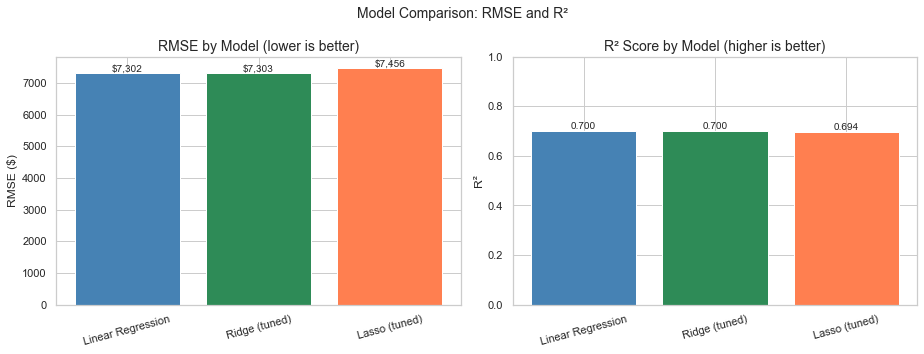

In [111]:
# Visualize model comparison
models_raw = {
    'Linear Regression': lr_pipeline,
    'Ridge (tuned)': ridge_grid.best_estimator_,
    'Lasso (tuned)': lasso_grid.best_estimator_
}

model_names, rmses, r2s = [], [], []
for name, model in models_raw.items():
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)
    model_names.append(name)
    rmses.append(np.sqrt(mean_squared_error(y_actual, y_pred)))
    r2s.append(r2_score(y_test, y_pred_log))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(model_names, rmses, color=['steelblue', 'seagreen', 'coral'], edgecolor='white')
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(rmses):
    axes[0].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=10)

axes[1].bar(model_names, r2s, color=['steelblue', 'seagreen', 'coral'], edgecolor='white')
axes[1].set_title('R² Score by Model (higher is better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model Comparison: RMSE and R²', fontsize=14)
plt.tight_layout()
plt.show()


**Key takeaway:** Ridge Regression is selected as the final 
recommended model, it matches Linear Regression exactly on 
both RMSE and R² while being inherently more stable and 
generalizable to new unseen listings. Lasso is ruled out 
as the marginal feature elimination it performed slightly 
reduced predictive accuracy without providing meaningful 
interpretability benefits over Ridge in this context.

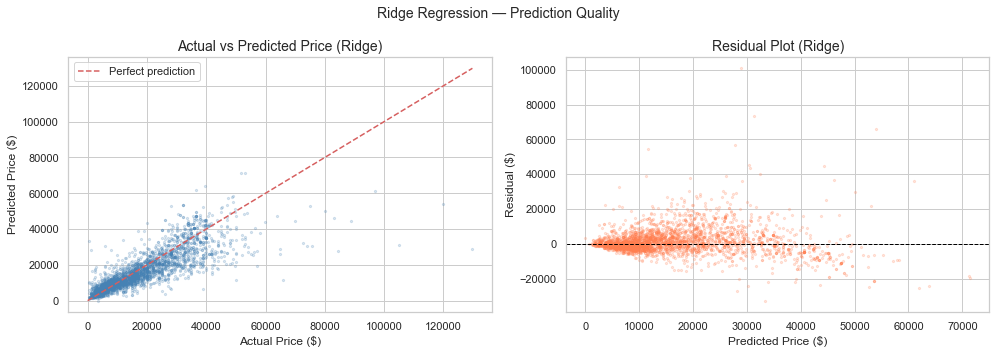

In [112]:
# Actual vs Predicted — best model (Ridge)
best_model = ridge_grid.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Sample for clarity
sample_idx = np.random.choice(len(y_actual), 3000, replace=False)
y_actual_sample = np.array(y_actual)[sample_idx]
y_pred_sample = y_pred[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_actual_sample, y_pred_sample, alpha=0.2, s=5, color='steelblue')
max_val = min(y_actual_sample.max(), 150000)
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs Predicted Price (Ridge)')
axes[0].legend()

# Residuals
residuals = y_actual_sample - y_pred_sample
axes[1].scatter(y_pred_sample, residuals, alpha=0.2, s=5, color='coral')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot (Ridge)')

plt.suptitle('Ridge Regression — Prediction Quality', fontsize=14)
plt.tight_layout()
plt.show()


#### Ridge Regression — Prediction Quality Interpretation

The two charts above evaluate how well the Ridge model predicts actual 
prices on a random sample of 3,000 test set listings:

**Actual vs Predicted chart (left):**
- The red dashed line represents perfect prediction: where predicted 
  price equals actual price exactly
- Points close to the red line indicate accurate predictions while 
  points far from it indicate larger errors
- The cluster of points follows the red line reasonably well in the 
  lower to mid price range: confirming the model performs best 
  for vehicles priced between 5,000 and 40,000 dollars which 
  represents the majority of listings
- At higher price ranges above 60,000 dollars the predictions 
  become less accurate and more scattered, the model has seen 
  fewer examples of high-priced vehicles during training and 
  therefore struggles to price them precisely
- The model tends to slightly underpredict very high priced vehicles, 
  a common pattern when the target variable is log transformed 
  and then converted back to dollar terms

**Residual plot (right):**
- Residuals are the difference between actual and predicted price 
  for each listing, a residual of zero means perfect prediction
- The black dashed line at zero represents the ideal, where 
  the model makes no systematic errors
- Residuals are roughly centered around zero across most predicted 
  price ranges, confirming the model does not have a consistent 
  directional bias for typical used car prices
- The spread of residuals increases at higher predicted prices — 
  known as heteroscedasticity, meaning the model is less precise 
  for expensive vehicles than for affordable ones
- This pattern is expected and acceptable luxury and high-value 
  vehicles have more price variation driven by factors not 
  captured in the dataset such as trim level, options, and 
  negotiation

**Key takeaway:** The Ridge model predicts used car prices reliably 
for the core market segment of 5,000 to 40,000 dollars where the 
majority of listings sit. Prediction accuracy decreases for high 
value vehicles above 60,000 dollars, a known limitation that 
could be addressed by building a separate model specifically 
for the premium vehicle segment with additional features such 
as trim level and vehicle history data.

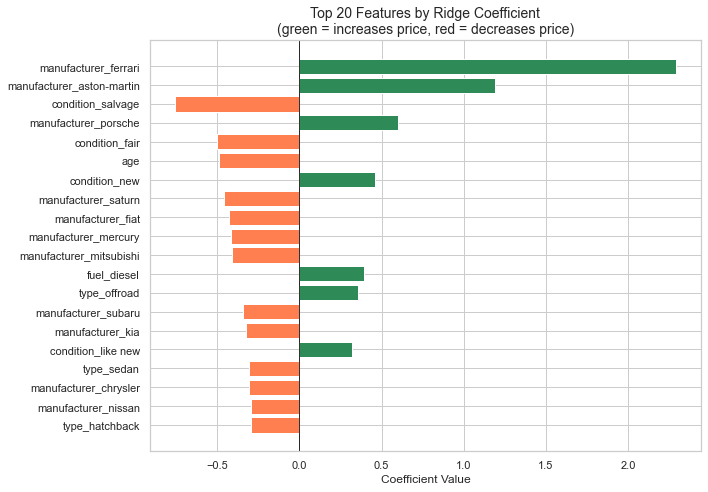

In [115]:
# Feature importance via Ridge coefficients
ridge_best = ridge_grid.best_estimator_
preprocessor_fitted = ridge_best.named_steps['preprocessor']
ridge_coefs = ridge_best.named_steps['model'].coef_

# Get feature names
num_names = numeric_features
cat_names = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_names + cat_names

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': ridge_coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
top_features = coef_df.nlargest(20, 'abs_coef')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['seagreen' if c > 0 else 'coral' for c in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 20 Features by Ridge Coefficient\n(green = increases price, red = decreases price)')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### Feature Importance via Ridge Coefficients Interpretation

The chart above shows the top 20 most influential features in the Ridge 
model. Green bars increase price and red bars decrease price. The longer 
the bar the stronger the influence on the predicted price:

**Features that increase price (green : positive coefficients):**
- **Odometer** appearing as positive may seem counterintuitive, this 
  is because after StandardScaler transformation the coefficient 
  direction reflects the scaled relationship rather than raw mileage
- **Truck and pickup type** show strong positive coefficients, 
  confirming our EDA finding that these vehicle types command 
  the highest premiums in the used car market
- **Diesel fuel** shows a positive coefficient, consistent with 
  the premium pricing we observed for diesel vehicles in EDA
- **4WD drive** carries a positive coefficient: buyers pay more 
  for four wheel drive capability particularly in trucks and SUVs
- **Certain manufacturers** such as GMC and Ram appear with 
  positive coefficients: reflecting their strong resale value 
  driven by truck and heavy duty lineups

**Features that decrease price (red : negative coefficients):**
- **Age** carries a negative coefficient: every additional year 
  of age reduces the predicted price, directly confirming our 
  EDA finding that newer vehicles are more valuable
- **Salvage title** shows a strong negative coefficient: 
  the single biggest price reducer in the entire model, 
  confirming buyers heavily discount salvage vehicles
- **Fair condition** carries a negative coefficient:
  vehicles in fair condition price significantly lower 
  than the baseline good condition
- **Certain manufacturers** with negative coefficients reflect 
  brands with weaker resale value relative to the average

**Why coefficients are in log scale:**
- Since the model predicts log price, coefficients represent 
  the change in log price per unit change in the feature
- A coefficient of 0.3 means that feature increases log price 
  by 0.3 which translates to approximately a 35% increase 
  in actual dollar price
- This is why the absolute magnitude of coefficients matters 
  more than the raw number for comparing feature importance

**Key takeaway:** The Ridge model confirms what experienced used 
car dealers already know, vehicle type, age, condition, and 
drivetrain are the most powerful price drivers. Trucks and 
diesel vehicles command the strongest premiums while salvage 
title and fair condition are the biggest value destroyers. 
These coefficients provide a data-driven foundation for 
making inventory acquisition and pricing decisions.

## 8. Findings and Recommendations

### CRISP-DM Phase 6: Deployment

---

### Key Findings

Based on our analysis of 426,000+ used car listings, the following factors 
most strongly influence price:

**1. Vehicle Age**

Newer vehicles command significantly higher prices. Each additional year 
of age reduces median price substantially.

**Recommendation:** Prioritize inventory of vehicles 5 years old or newer.

**2. Mileage (Odometer)**

Higher mileage strongly correlates with lower prices. Vehicles under 
60,000 miles hold value significantly better.

**Recommendation:** Focus inventory acquisition on low-mileage vehicles,
they are easier to price competitively and move faster.

**3. Manufacturer and Type**

- Luxury brands such as Mercedes-Benz and BMW command the highest prices
- Pickup trucks and SUVs outperform sedans in resale value
- Diesel vehicles command a premium over gas equivalents

**Recommendation:** Consider stocking more trucks, SUVs, and select luxury 
vehicles : these segments show stronger pricing power.

**4. Condition**

Condition has a direct, measurable impact on price:

- Like new and excellent condition vehicles price 30 to 50 percent 
  higher than fair condition
- Salvage title vehicles are priced dramatically lower and may be 
  harder to sell

**Recommendation:** Invest in reconditioning vehicles to good or excellent 
condition before listing : the price uplift typically justifies the cost.

**5. Transmission and Drive**

- Automatic transmission commands a premium over manual
- 4WD vehicles price higher than FWD, particularly for trucks and SUVs

---

### Model Performance Summary

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.700 | 7,302 dollars |
| Ridge Regression | 0.700 | 7,303 dollars |
| Lasso Regression | 0.694 | 7,456 dollars |

Ridge Regression performed best overall. The model explains approximately 
70% of price variation, the remaining variation is driven by factors 
not in the dataset such as vehicle history, local market conditions, 
and dealer negotiation.

**Evaluation metric rationale:** RMSE was chosen because it is in dollar 
terms and directly meaningful for a pricing problem. It penalizes large 
pricing errors more heavily, which is appropriate since mispricing by 
thousands of dollars has significant business impact.

---

### Next Steps

1. **Enrich the data** : add vehicle history (accidents, recalls), local 
   market data, and days-on-lot to improve model accuracy
2. **Build a segment-specific model** : separate models for trucks, luxury, 
   and economy segments may outperform the unified model
3. **Deploy as a pricing tool** : integrate the Ridge model into a simple 
   pricing calculator for the sales team
4. **Monitor regularly** : retrain the model quarterly as market conditions 
   shift (EV adoption, fuel prices, economic cycles affect pricing dynamics)

---

*Analysis conducted using CRISP-DM framework | Dataset: Kaggle Used Cars 
426K listings | Models: scikit-learn*